In [1]:
import numpy as np
import os
import PcmPy as pcm
import matplotlib.pyplot as plt
from pcm_models import find_model, normalize_Ac
import globals as gl

def plot_features(model):
    num_feature = model.Ac.shape[0]
    for i in range(num_feature):
        plt.subplot(1, num_feature, i+1)
        plt.imshow(model.Ac[i], cmap='seismic',vmin=-1, vmax=1)

C = pcm.centering(8)

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


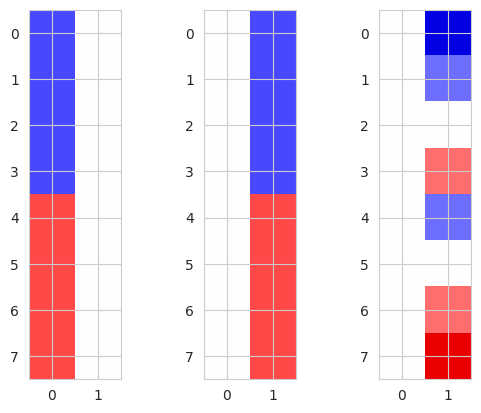

In [2]:
Mf, idxf = find_model(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'M.exec.p'), 'feature')

plot_features(Mf)

In [8]:
theta = np.array([1, 1, 1])
Ac_s = (Mf.Ac * theta[:, None, None]).sum(axis=0)
Ac_s

array([[-0.35355339, -0.93090366],
       [-0.35355339, -0.64222853],
       [-0.35355339, -0.35355339],
       [-0.35355339, -0.06487826],
       [ 0.35355339,  0.06487826],
       [ 0.35355339,  0.35355339],
       [ 0.35355339,  0.64222853],
       [ 0.35355339,  0.93090366]])

In [10]:
W = np.array([[theta[0], theta[1]], [0, theta[2]]])
v_finger = C @ np.array([-1, -1, -1, -1, 1, 1, 1, 1])
v_cue = C @ np.array([-1, -.5, 0, .5, -.5, 0, .5, 1])
v_finger=v_finger/np.sqrt(np.sum(v_finger**2))
v_cue=v_cue/np.sqrt(np.sum(v_cue**2))
M = np.c_[v_finger, v_cue]
U = M @ W
U

array([[-0.35355339, -0.93090366],
       [-0.35355339, -0.64222853],
       [-0.35355339, -0.35355339],
       [-0.35355339, -0.06487826],
       [ 0.35355339,  0.06487826],
       [ 0.35355339,  0.35355339],
       [ 0.35355339,  0.64222853],
       [ 0.35355339,  0.93090366]])